In [1]:
from datasets import load_dataset
import json
from pprint import pprint

/home/charis/Desktop/Projects/LLava-next---finetuning/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("naver-clova-ix/cord-v2")
dataset.shape

Generating test split: 100%|██████████| 100/100 [00:02<00:00, 39.88 examples/s]


{'train': (800, 2), 'validation': (100, 2), 'test': (100, 2)}

In [3]:
sample_data = dataset['train'][1]
sample_data

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=864x1296>,
 'ground_truth': '{"gt_parse": {"menu": [{"nm": "SPGTHY BOLOGNASE", "cnt": "1", "price": "58,000"}, {"nm": "PEPPER AUS", "cnt": "1", "price": "165,000", "sub": {"nm": "WELL DONE"}}, {"nm": "WAGYU RIBEYE", "cnt": "1", "price": "195,000", "sub": {"nm": "MEDIUM WELL"}}, {"nm": "ICED LEMON TEA", "cnt": "1", "price": "22,000"}, {"nm": "FUSION TEA LYCHE", "cnt": "1", "price": "28,000"}, {"nm": "NUTTELA BROWNIES", "cnt": "1", "price": "35,000"}], "sub_total": {"subtotal_price": "503,000", "service_price": "25,150", "tax_price": "52,815"}, "total": {"total_price": "580,965"}}, "meta": {"version": "2.0.0", "split": "train", "image_id": 1, "image_size": {"width": 864, "height": 1296}}, "valid_line": [{"words": [{"quad": {"x2": 74, "y3": 512, "x3": 74, "y4": 512, "x1": 56, "y1": 480, "x4": 56, "y2": 480}, "is_key": 0, "row_id": 2252526, "text": "1"}], "category": "menu.cnt", "group_id": 3, "sub_group_id": 0}, {"words": [{"q

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})

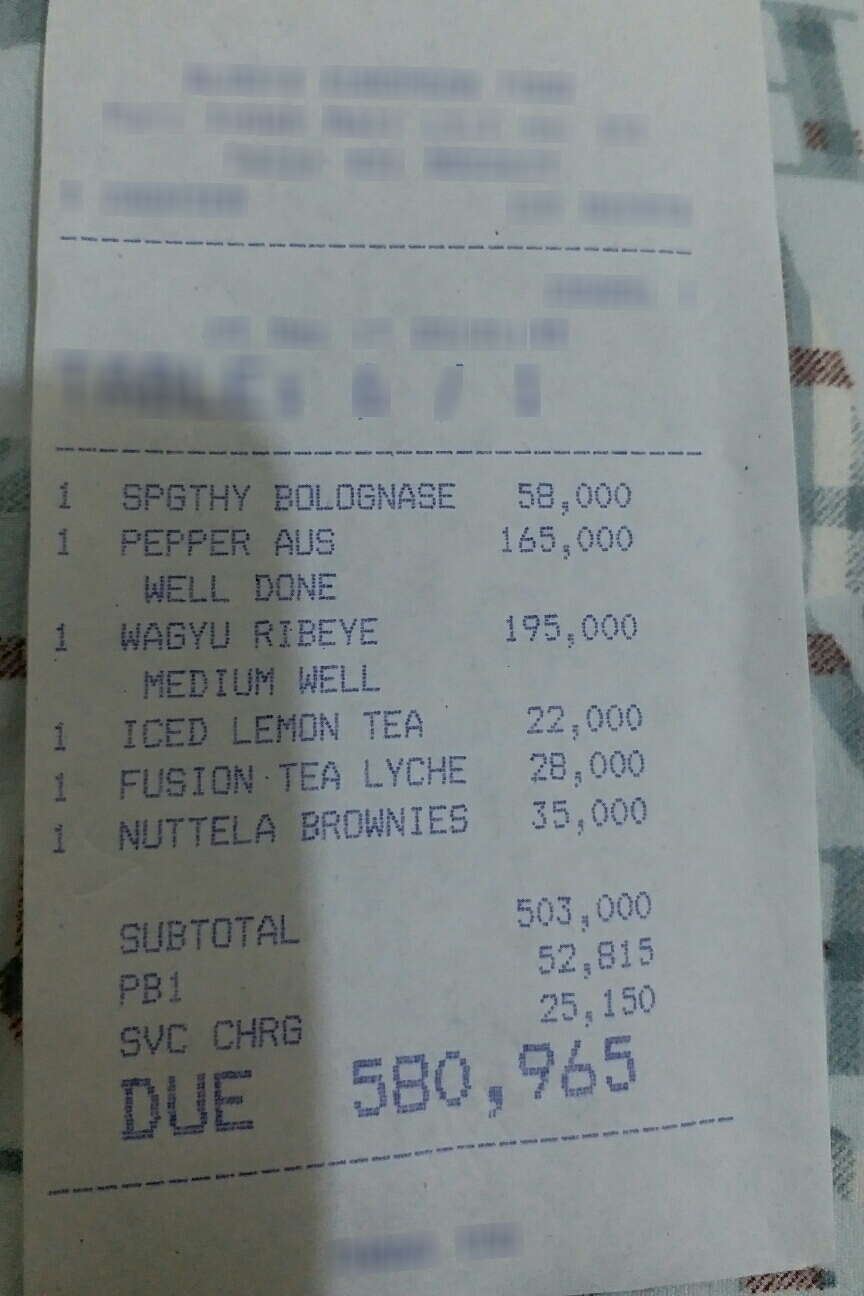

In [5]:
sample_data['image']

In [14]:
sample_data['ground_truth']

'{"gt_parse": {"menu": [{"nm": "SPGTHY BOLOGNASE", "cnt": "1", "price": "58,000"}, {"nm": "PEPPER AUS", "cnt": "1", "price": "165,000", "sub": {"nm": "WELL DONE"}}, {"nm": "WAGYU RIBEYE", "cnt": "1", "price": "195,000", "sub": {"nm": "MEDIUM WELL"}}, {"nm": "ICED LEMON TEA", "cnt": "1", "price": "22,000"}, {"nm": "FUSION TEA LYCHE", "cnt": "1", "price": "28,000"}, {"nm": "NUTTELA BROWNIES", "cnt": "1", "price": "35,000"}], "sub_total": {"subtotal_price": "503,000", "service_price": "25,150", "tax_price": "52,815"}, "total": {"total_price": "580,965"}}, "meta": {"version": "2.0.0", "split": "train", "image_id": 1, "image_size": {"width": 864, "height": 1296}}, "valid_line": [{"words": [{"quad": {"x2": 74, "y3": 512, "x3": 74, "y4": 512, "x1": 56, "y1": 480, "x4": 56, "y2": 480}, "is_key": 0, "row_id": 2252526, "text": "1"}], "category": "menu.cnt", "group_id": 3, "sub_group_id": 0}, {"words": [{"quad": {"x2": 252, "y3": 514, "x3": 252, "y4": 514, "x1": 118, "y1": 480, "x4": 118, "y2": 4

In [15]:
pprint(sample_data['ground_truth'])

('{"gt_parse": {"menu": [{"nm": "SPGTHY BOLOGNASE", "cnt": "1", "price": '
 '"58,000"}, {"nm": "PEPPER AUS", "cnt": "1", "price": "165,000", "sub": '
 '{"nm": "WELL DONE"}}, {"nm": "WAGYU RIBEYE", "cnt": "1", "price": "195,000", '
 '"sub": {"nm": "MEDIUM WELL"}}, {"nm": "ICED LEMON TEA", "cnt": "1", "price": '
 '"22,000"}, {"nm": "FUSION TEA LYCHE", "cnt": "1", "price": "28,000"}, {"nm": '
 '"NUTTELA BROWNIES", "cnt": "1", "price": "35,000"}], "sub_total": '
 '{"subtotal_price": "503,000", "service_price": "25,150", "tax_price": '
 '"52,815"}, "total": {"total_price": "580,965"}}, "meta": {"version": '
 '"2.0.0", "split": "train", "image_id": 1, "image_size": {"width": 864, '
 '"height": 1296}}, "valid_line": [{"words": [{"quad": {"x2": 74, "y3": 512, '
 '"x3": 74, "y4": 512, "x1": 56, "y1": 480, "x4": 56, "y2": 480}, "is_key": 0, '
 '"row_id": 2252526, "text": "1"}], "category": "menu.cnt", "group_id": 3, '
 '"sub_group_id": 0}, {"words": [{"quad": {"x2": 252, "y3": 514, "x3": 252, '


# Convert the string dict to json

In [16]:
sample_data_ground_truth_json = json.loads(sample_data["ground_truth"])
sample_data_ground_truth_json

{'gt_parse': {'menu': [{'nm': 'SPGTHY BOLOGNASE',
    'cnt': '1',
    'price': '58,000'},
   {'nm': 'PEPPER AUS',
    'cnt': '1',
    'price': '165,000',
    'sub': {'nm': 'WELL DONE'}},
   {'nm': 'WAGYU RIBEYE',
    'cnt': '1',
    'price': '195,000',
    'sub': {'nm': 'MEDIUM WELL'}},
   {'nm': 'ICED LEMON TEA', 'cnt': '1', 'price': '22,000'},
   {'nm': 'FUSION TEA LYCHE', 'cnt': '1', 'price': '28,000'},
   {'nm': 'NUTTELA BROWNIES', 'cnt': '1', 'price': '35,000'}],
  'sub_total': {'subtotal_price': '503,000',
   'service_price': '25,150',
   'tax_price': '52,815'},
  'total': {'total_price': '580,965'}},
 'meta': {'version': '2.0.0',
  'split': 'train',
  'image_id': 1,
  'image_size': {'width': 864, 'height': 1296}},
 'valid_line': [{'words': [{'quad': {'x2': 74,
      'y3': 512,
      'x3': 74,
      'y4': 512,
      'x1': 56,
      'y1': 480,
      'x4': 56,
      'y2': 480},
     'is_key': 0,
     'row_id': 2252526,
     'text': '1'}],
   'category': 'menu.cnt',
   'group_id': 3

In [17]:
sample_data_ground_truth_json['gt_parse']

{'menu': [{'nm': 'SPGTHY BOLOGNASE', 'cnt': '1', 'price': '58,000'},
  {'nm': 'PEPPER AUS',
   'cnt': '1',
   'price': '165,000',
   'sub': {'nm': 'WELL DONE'}},
  {'nm': 'WAGYU RIBEYE',
   'cnt': '1',
   'price': '195,000',
   'sub': {'nm': 'MEDIUM WELL'}},
  {'nm': 'ICED LEMON TEA', 'cnt': '1', 'price': '22,000'},
  {'nm': 'FUSION TEA LYCHE', 'cnt': '1', 'price': '28,000'},
  {'nm': 'NUTTELA BROWNIES', 'cnt': '1', 'price': '35,000'}],
 'sub_total': {'subtotal_price': '503,000',
  'service_price': '25,150',
  'tax_price': '52,815'},
 'total': {'total_price': '580,965'}}

In [18]:
sample_data_ground_truth_json.keys()

dict_keys(['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare'])

In [22]:
sample_data_ground_truth_json['meta']

{'version': '2.0.0',
 'split': 'train',
 'image_id': 1,
 'image_size': {'width': 864, 'height': 1296}}